Cell 1: Khai báo các thư viện cần thiết

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, f1_score

Cell 2: Đọc dữ liệu từ các file CSV

In [ ]:
# Đọc các file dữ liệu
data_model = pd.read_csv('data_model.csv')
train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
test = pd.read_csv('test.csv')

print(f"Kích thước tập dữ liệu gốc data_model: {data_model.shape}")
print(f"Kích thước tập huấn luyện của bạn (train): {train.shape}")
print(f"Kích thước tập phát triển của bạn (val): {val.shape}")
print(f"Kích thước tập kiểm thử của bạn (test): {test.shape}")

Kích thước tập dữ liệu gốc data_model: (5190, 18)
Kích thước tập huấn luyện của bạn (train): (4152, 11)
Kích thước tập phát triển của bạn (val): (519, 11)
Kích thước tập kiểm thử của bạn (test): (519, 11)


Cell 3: Thực hiện khớp (Matching) để lấy đúng cột văn bản svm

In [ ]:
# Tạo bảng ánh xạ duy nhất từ cột 'qwen' sang cột 'svm' của dữ liệu gốc data_model
# Do mỗi chuỗi văn bản trong 'qwen' tương ứng với đúng một chuỗi trong 'svm', ta loại bỏ trùng lặp trước khi lưu từ điển
mapping = data_model.drop_duplicates(subset=['qwen']).set_index('qwen')['svm']

# Ánh xạ cột 'review' (đóng vai trò là qwen) trong các tập train, val, test sang dữ liệu văn bản hệ 'svm'
train['svm_text'] = train['review'].map(mapping)
val['svm_text'] = val['review'].map(mapping)
test['svm_text'] = test['review'].map(mapping)

# Kiểm tra và loại bỏ các dòng bị khuyết thiếu (nếu có) để đảm bảo tính toàn vẹn dữ liệu
train = train.dropna(subset=['svm_text'])
val = val.dropna(subset=['svm_text'])
test = test.dropna(subset=['svm_text'])

print("Khớp dữ liệu thành công! Cột dữ liệu mới 'svm_text' đã được chuẩn bị.")
print(train[['review', 'svm_text']].head(3))

Khớp dữ liệu thành công! Cột dữ liệu mới 'svm_text' đã được chuẩn bị.
                                              review  \
0  cơ chế tính kda thì như tệ hại afk với phá thì...   
1  có này chơi thì cứ vào là bị xếp với mấy kid t...   
2  nhân phẩm tài khoản đen nạp mua gương không tr...   

                                            svm_text  
0  cơ_chế tính kda thì như tệ_hại afk với phá thì...  
1  có này chơi thì cứ vào là bị xếp với mấy kid t...  
2  nhân_phẩm tài_khoản đen nạp mua gương không_tr...  


Cell 4: Tách Đặc trưng (X) và Nhãn khía cạnh (Y) kết hợp Vector hóa TF-IDF

In [ ]:
# Tự động trích xuất danh sách các cột khía cạnh (aspects) dựa trên các cột nhãn
aspect_cols = [col for col in train.columns if col not in ['review', 'svm_text']]
print(f"Tìm thấy tất cả {len(aspect_cols)} khía cạnh cần dự đoán bao gồm:\n{aspect_cols}\n")

# Phân chia ma trận nhãn mục tiêu Y
Y_train = train[aspect_cols]
Y_val = val[aspect_cols]
Y_test = test[aspect_cols]

# Vector hóa văn bản bằng thuật toán TF-IDF
# Thiết lập sử dụng thêm cả cụm từ (ngram_range=(1, 2)) phù hợp cao với từ ghép Tiếng Việt đã được phân tách (_) trong cột SVM
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2)

X_train = vectorizer.fit_transform(train['svm_text'])
X_val = vectorizer.transform(val['svm_text'])
X_test = vectorizer.transform(test['svm_text'])

print(f"Kích thước ma trận đặc trưng X_train sau TF-IDF: {X_train.shape}")

Tìm thấy tất cả 10 khía cạnh cần dự đoán bao gồm:
['graphics', 'matchmaking', 'store & microtransactions', 'technical_issue', 'mechanics', 'developer_support', 'event', 'community', 'hero_design', 'difficulty']

Kích thước ma trận đặc trưng X_train sau TF-IDF: (4152, 9136)


Cell 5: Xây dựng và Huấn luyện mô hình SVM MultiOutputClassifier

In [ ]:
# Sử dụng LinearSVC làm lõi SVM cơ bản nhờ tốc độ xử lý nhanh và độ chính xác cao trên không gian đặc trưng thưa (văn bản)
# MultiOutputClassifier giúp tự động nhân bản và chạy song song độc lập các bộ phân lớp SVM cho từng cột khía cạnh riêng biệt
base_svm = LinearSVC(C=1.0, random_state=42, max_iter=10000)
multi_output_svm = MultiOutputClassifier(base_svm)

# Tiến hành huấn luyện mô hình
print("Đang chạy huấn luyện hệ thống các mô hình SVM độc lập kết hợp...")
multi_output_svm.fit(X_train, Y_train)
print("Huấn luyện mô hình thành công!")

Đang chạy huấn luyện hệ thống các mô hình SVM độc lập kết hợp...
Huấn luyện mô hình thành công!


Cell 6: Dự đoán và Đánh giá chi tiết trên các tập dữ liệu

In [ ]:
# Thực hiện dự đoán trên tập Validation và Test
Y_pred_val = multi_output_svm.predict(X_val)
Y_pred_test = multi_output_svm.predict(X_test)

# Định nghĩa hàm hiển thị báo cáo phân loại chi tiết và tính toán Macro F1 trung bình
def evaluate_absa_performance(Y_true, Y_pred, dataset_name="Test"):
    print("=" * 70)
    print(f"BÁO CÁO ĐÁNH GIÁ CHI TIẾT TRÊN TẬP {dataset_name.upper()}")
    print("=" * 70)

    macro_f1_scores = []
    for idx, col in enumerate(aspect_cols):
        print(f"\nKhía cạnh: [ {col} ]")
        # In báo cáo Precision, Recall, F1-score cho từng khía cạnh
        print(classification_report(Y_true.iloc[:, idx], Y_pred[:, idx], zero_division=0))

        # Lưu điểm số Macro F1 của khía cạnh hiện tại
        score = f1_score(Y_true.iloc[:, idx], Y_pred[:, idx], average='macro', zero_division=0)
        macro_f1_scores.append(score)

    avg_macro_f1 = np.mean(macro_f1_scores)
    print("\n" + "-" * 50)
    print(f"--> Điểm tổng thể (Average Macro $F_1$ Score) trên {dataset_name}: {avg_macro_f1:.4f}")
    print("-" * 50)
    return avg_macro_f1

# Đánh giá hiệu năng trên cả hai tập dữ liệu
val_f1 = evaluate_absa_performance(Y_val, Y_pred_val, dataset_name="Validation")
test_f1 = evaluate_absa_performance(Y_test, Y_pred_test, dataset_name="Test")

BÁO CÁO ĐÁNH GIÁ CHI TIẾT TRÊN TẬP VALIDATION

Khía cạnh: [ graphics ]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       500
           1       1.00      0.08      0.15        12
           2       1.00      0.14      0.25         7

    accuracy                           0.97       519
   macro avg       0.99      0.41      0.46       519
weighted avg       0.97      0.97      0.95       519


Khía cạnh: [ matchmaking ]
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       378
           1       0.00      0.00      0.00         2
           2       0.86      0.85      0.85       139

    accuracy                           0.92       519
   macro avg       0.60      0.60      0.60       519
weighted avg       0.92      0.92      0.92       519


Khía cạnh: [ store & microtransactions ]
              precision    recall  f1-score   support

           0       0.97      1.00      0.9

# Cải thiện


Cell 1: Khai báo các thư viện cần thiết

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, f1_score

Cell 2: Đọc dữ liệu từ các file CSV

In [ ]:
# Đọc các file dữ liệu
data_model = pd.read_csv('data_model.csv')
train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
test = pd.read_csv('test.csv')

print(f"Kích thước tập dữ liệu gốc data_model: {data_model.shape}")
print(f"Kích thước tập huấn luyện (train): {train.shape}")
print(f"Kích thước tập phát triển (val): {val.shape}")
print(f"Kích thước tập kiểm thử (test): {test.shape}")

Kích thước tập dữ liệu gốc data_model: (5190, 18)
Kích thước tập huấn luyện (train): (4152, 11)
Kích thước tập phát triển (val): (519, 11)
Kích thước tập kiểm thử (test): (519, 11)


Cell 3: Thực hiện khớp (Matching) dữ liệu để lấy cột văn bản hệ svm

In [ ]:
# Tạo bảng ánh xạ duy nhất từ cột 'qwen' sang cột 'svm' của dữ liệu gốc data_model
mapping = data_model.drop_duplicates(subset=['qwen']).set_index('qwen')['svm']

# Ánh xạ cột 'review' trong các tập train, val, test sang dữ liệu văn bản hệ 'svm'
train['svm_text'] = train['review'].map(mapping)
val['svm_text'] = val['review'].map(mapping)
test['svm_text'] = test['review'].map(mapping)

# Loại bỏ các dòng bị khuyết thiếu (nếu có)
train = train.dropna(subset=['svm_text'])
val = val.dropna(subset=['svm_text'])
test = test.dropna(subset=['svm_text'])

print("Khớp dữ liệu thành công! Hệ văn bản 'svm_text' đã được áp dụng.")

Khớp dữ liệu thành công! Hệ văn bản 'svm_text' đã được áp dụng.


Cell 4: Phân tách Nhãn mục tiêu & Cải tiến cấu hình Vector hóa TF-IDF (N-gram 1-3)

In [ ]:
# Tự động trích xuất danh sách các cột khía cạnh (aspects) dựa trên các cột nhãn
aspect_cols = [col for col in train.columns if col not in ['review', 'svm_text']]
print(f"Tìm thấy tất cả {len(aspect_cols)} khía cạnh cần dự đoán.\n")

# Phân chia ma trận nhãn mục tiêu Y
Y_train = train[aspect_cols]
Y_val = val[aspect_cols]
Y_test = test[aspect_cols]

# CẢI TIẾN 1: Sử dụng ngram_range=(1, 3) để bắt trọn cấu trúc ngữ nghĩa Tiếng Việt tốt hơn
vectorizer = TfidfVectorizer(ngram_range=(1, 3), min_df=2)

X_train = vectorizer.fit_transform(train['svm_text'])
X_val = vectorizer.transform(val['svm_text'])
X_test = vectorizer.transform(test['svm_text'])

print(f"Kích thước ma trận đặc trưng X_train sau cải tiến TF-IDF: {X_train.shape}")

Tìm thấy tất cả 10 khía cạnh cần dự đoán.

Kích thước ma trận đặc trưng X_train sau cải tiến TF-IDF: (4152, 13440)


Cell 5: Huấn luyện SVM MultiOutputClassifier với thiết lập Cân bằng trọng số nhãn

In [ ]:
# CẢI TIẾN 2: Thêm class_weight='balanced' để tối ưu cho dữ liệu mất cân bằng nhãn nặng
# CẢI TIẾN 3: Tinh chỉnh C=0.5 để kiểm soát hiện tượng quá khớp (overfitting)
base_svm = LinearSVC(C=0.5, class_weight='balanced', random_state=42, max_iter=10000)
multi_output_svm = MultiOutputClassifier(base_svm)

print("Đang huấn luyện tổ hợp các mô hình SVM cải tiến độc lập...")
multi_output_svm.fit(X_train, Y_train)
print("Huấn luyện mô hình thành công!")

Đang huấn luyện tổ hợp các mô hình SVM cải tiến độc lập...
Huấn luyện mô hình thành công!


Cell 6: Dự đoán và Đánh giá kết quả cải tiến

In [ ]:
# Thực hiện dự đoán trên tập Validation và Test bằng mô hình mới
Y_pred_val = multi_output_svm.predict(X_val)
Y_pred_test = multi_output_svm.predict(X_test)

def evaluate_absa_performance(Y_true, Y_pred, dataset_name="Test"):
    print("=" * 70)
    print(f"BÁO CÁO ĐÁNH GIÁ TRÊN TẬP {dataset_name.upper()}")
    print("=" * 70)

    macro_f1_scores = []
    for idx, col in enumerate(aspect_cols):
        print(f"\nKhía cạnh: [ {col} ]")
        print(classification_report(Y_true.iloc[:, idx], Y_pred[:, idx], zero_division=0))

        score = f1_score(Y_true.iloc[:, idx], Y_pred[:, idx], average='macro', zero_division=0)
        macro_f1_scores.append(score)

    avg_macro_f1 = np.mean(macro_f1_scores)
    print("\n" + "-" * 50)
    print(f"--> Trung bình điểm Macro F1 trên tập {dataset_name}: {avg_macro_f1:.4f}")
    print("-" * 50)
    return avg_macro_f1

# Hiển thị báo cáo kết quả
val_f1 = evaluate_absa_performance(Y_val, Y_pred_val, dataset_name="Validation")
test_f1 = evaluate_absa_performance(Y_test, Y_pred_test, dataset_name="Test")

BÁO CÁO ĐÁNH GIÁ TRÊN TẬP VALIDATION

Khía cạnh: [ graphics ]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       500
           1       0.75      0.25      0.38        12
           2       1.00      0.14      0.25         7

    accuracy                           0.97       519
   macro avg       0.91      0.46      0.54       519
weighted avg       0.97      0.97      0.96       519


Khía cạnh: [ matchmaking ]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       378
           1       0.00      0.00      0.00         2
           2       0.84      0.85      0.84       139

    accuracy                           0.92       519
   macro avg       0.59      0.60      0.60       519
weighted avg       0.91      0.92      0.91       519


Khía cạnh: [ store & microtransactions ]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       4

# Bảng kết quả

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def get_detailed_metrics_dataframe(Y_true, Y_pred, dataset_name="Test"):
    results_list = []

    # Duyệt qua từng cột khía cạnh để tính toán 4 chỉ số
    for idx, col in enumerate(aspect_cols):
        # Tính Accuracy cho khía cạnh hiện tại
        acc = accuracy_score(Y_true.iloc[:, idx], Y_pred[:, idx])

        # Tính Macro Precision, Macro Recall, Macro F1-score
        p, r, f1, _ = precision_recall_fscore_support(
            Y_true.iloc[:, idx],
            Y_pred[:, idx],
            average='macro',
            zero_division=0
        )

        # Lưu kết quả vào danh sách
        results_list.append({
            "Khía Cạnh (Aspect)": col,
            "Accuracy": round(acc, 4),
            "Precision (Macro)": round(p, 4),
            "Recall (Macro)": round(r, 4),
            "F1-Score (Macro)": round(f1, 4)
        })

    # Chuyển đổi thành bảng DataFrame
    df_res = pd.DataFrame(results_list)

    # Tính dòng trung bình tổng cho tất cả các khía cạnh
    mean_row = {
        "Khía Cạnh (Aspect)": "TRUNG BÌNH TỔNG (AVERAGE)",
        "Accuracy": round(df_res["Accuracy"].mean(), 4),
        "Precision (Macro)": round(df_res["Precision (Macro)"].mean(), 4),
        "Recall (Macro)": round(df_res["Recall (Macro)"].mean(), 4),
        "F1-Score (Macro)": round(df_res["F1-Score (Macro)"].mean(), 4)
    }

    # Nối dòng trung bình vào cuối bảng
    df_res = pd.concat([df_res, pd.DataFrame([mean_row])], ignore_index=True)
    return df_res

# --- THỰC THI VÀ IN KẾT QUẢ ---

# 1. Tính toán bảng kết quả cho tập Validation
df_val_metrics = get_detailed_metrics_dataframe(Y_val, Y_pred_val, dataset_name="Validation")
print("=" * 75)
print("BẢNG CHỈ SỐ CHI TIẾT TRÊN TẬP VALIDATION")
print("=" * 75)
print(df_val_metrics.to_string(index=False)) # In toàn bộ bảng không hiện chỉ số dòng ngẫu nhiên
print("\n" + "#"*75 + "\n")

# 2. Tính toán bảng kết quả cho tập Test
df_test_metrics = get_detailed_metrics_dataframe(Y_test, Y_pred_test, dataset_name="Test")
print("=" * 75)
print("BẢNG CHỈ SỐ CHI TIẾT TRÊN TẬP TEST")
print("=" * 75)
print(df_test_metrics.to_string(index=False))

BẢNG CHỈ SỐ CHI TIẾT TRÊN TẬP VALIDATION
       Khía Cạnh (Aspect)  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)
                 graphics    0.9692             0.9069          0.4636            0.5364
              matchmaking    0.9152             0.5938          0.5978            0.5958
store & microtransactions    0.9730             0.5927          0.5231            0.5515
          technical_issue    0.9306             0.6204          0.6240            0.6222
                mechanics    0.8882             0.5494          0.5579            0.5536
        developer_support    0.8574             0.7652          0.7339            0.7458
                    event    0.9865             0.6628          0.4993            0.5533
                community    0.9287             0.6091          0.6088            0.6089
              hero_design    0.9634             0.8937          0.5616            0.6138
               difficulty    0.9750             0.3256          0.332

Cell 7: Lưu mô hình và bộ Vectorizer thành file

In [ ]:
# Đường dẫn đặt tên file lưu trữ
model_filename = 'svm_multioutput_absa_model.pkl'
vectorizer_filename = 'tfidf_vectorizer_absa.pkl'

# Thực hiện lưu mô hình và bộ vectorizer
joblib.dump(multi_output_svm, model_filename)
joblib.dump(vectorizer, vectorizer_filename)

print(f"Đã lưu thành công mô hình vào file: {model_filename}")
print(f"Đã lưu thành công bộ vectorizer vào file: {vectorizer_filename}")

Đã lưu thành công mô hình vào file: svm_multioutput_absa_model.pkl
Đã lưu thành công bộ vectorizer vào file: tfidf_vectorizer_absa.pkl


# Thử nghiệm N gram khác nhau

In [ ]:
# Cell này dùng để thử nghiệm nhanh ảnh hưởng của các dải N-gram khác nhau
for n_range in [(1, 2), (1, 3), (1, 4)]:
    # Cấu hình Vectorizer với n_range thử nghiệm
    test_vec = TfidfVectorizer(ngram_range=n_range, min_df=2)

    X_tr = test_vec.fit_transform(train['svm_text'])
    X_te = test_vec.transform(test['svm_text'])

    # Huấn luyện mô hình cải tiến
    test_model = MultiOutputClassifier(LinearSVC(C=0.5, class_weight='balanced', random_state=42, max_iter=10000))
    test_model.fit(X_tr, Y_train)

    # Dự đoán và tính toán Macro F1 trung bình trên tập Test
    preds = test_model.predict(X_te)

    scores = []
    for idx in range(len(aspect_cols)):
        scores.append(f1_score(Y_test.iloc[:, idx], preds[:, idx], average='macro', zero_division=0))

    print(f"Cấu hình ngram_range={n_range} --> Số đặc trưng: {X_tr.shape[1]} | Thử nghiệm Trung bình Macro F1: {np.mean(scores):.4f}")

Cấu hình ngram_range=(1, 2) --> Số đặc trưng: 9136 | Thử nghiệm Trung bình Macro F1: 0.5379
Cấu hình ngram_range=(1, 3) --> Số đặc trưng: 13440 | Thử nghiệm Trung bình Macro F1: 0.5388
Cấu hình ngram_range=(1, 4) --> Số đặc trưng: 14828 | Thử nghiệm Trung bình Macro F1: 0.5356


Cell 8: Lưu file cấu hình huấn luyện (train_config.json)

In [ ]:

import json
train_config = {
    "model_architecture": "MultiOutputClassifier(LinearSVC)",
    "svm_hyperparameters": {
        "C": 0.5,
        "class_weight": "balanced",
        "random_state": 42,
        "max_iter": 10000,
        "loss": "squared_hinge"
    },
    "vectorizer_hyperparameters": {
        "method": "TF-IDF",
        "ngram_range": [1, 3],
        "min_df": 2,
        "analyzer": "word"
    },
    "dataset_info": {
        "train_size": X_train.shape[0],
        "val_size": X_val.shape[0],
        "test_size": X_test.shape[0],
        "total_features": X_train.shape[1],
        "number_of_aspects": len(aspect_cols),
        "aspect_list": aspect_cols
    }
}

# Lưu thành file JSON
with open('train_config.json', 'w', encoding='utf-8') as f:
    json.dump(train_config, f, ensure_ascii=False, indent=4)

print("Đã lưu file cấu hình: train_config.json")

Đã lưu file cấu hình: train_config.json


Cell 9: Lưu file Kết quả chi tiết của từng khía cạnh (evaluation_results.csv)

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

results_list = []

# Tính toán chỉ số cho từng khía cạnh
for idx, col in enumerate(aspect_cols):
    # Lấy điểm Macro cho từng cột khía cạnh
    p, r, f1, _ = precision_recall_fscore_support(Y_test.iloc[:, idx], Y_pred_test[:, idx], average='macro', zero_division=0)

    results_list.append({
        "Aspect": col,
        "Macro_Precision": round(p, 4),
        "Macro_Recall": round(r, 4),
        "Macro_F1_Score": round(f1, 4)
    })

# Chuyển thành DataFrame và thêm dòng trung bình tổng (đạt ~0.5388)
df_results = pd.DataFrame(results_list)
mean_row = {
    "Aspect": "AVERAGE_TOTAL",
    "Macro_Precision": round(df_results["Macro_Precision"].mean(), 4),
    "Macro_Recall": round(df_results["Macro_Recall"].mean(), 4),
    "Macro_F1_Score": round(df_results["Macro_F1_Score"].mean(), 4)
}
df_results = pd.concat([df_results, pd.DataFrame([mean_row])], ignore_index=True)

# Xuất ra file CSV
df_results.to_csv('evaluation_results.csv', index=False, encoding='utf-8')
print("Đã lưu bảng kết quả chi tiết: evaluation_results.csv")
print(df_results)

Đã lưu bảng kết quả chi tiết: evaluation_results.csv
                       Aspect  Macro_Precision  Macro_Recall  Macro_F1_Score
0                    graphics           0.5774        0.4524          0.4736
1                 matchmaking           0.5964        0.5967          0.5966
2   store & microtransactions           0.5229        0.3853          0.4111
3             technical_issue           0.6057        0.6051          0.6052
4                   mechanics           0.7004        0.6172          0.6446
5           developer_support           0.6789        0.6955          0.6861
6                       event           0.3301        0.3307          0.3304
7                   community           0.6145        0.6142          0.6143
8                 hero_design           0.8824        0.5650          0.6532
9                  difficulty           0.4916        0.3577          0.3729
10              AVERAGE_TOTAL           0.6000        0.5220          0.5388


# Phân tích lỗi

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import confusion_matrix

Cell 2: Phần 1 - Vẽ Ma trận nhầm lẫn (Confusion Matrix) cho từng khía cạnh

--- ĐANG ĐỒ THỊ HÓA MA TRẬN NHẦM LẪN TRÊN TẬP TEST ---


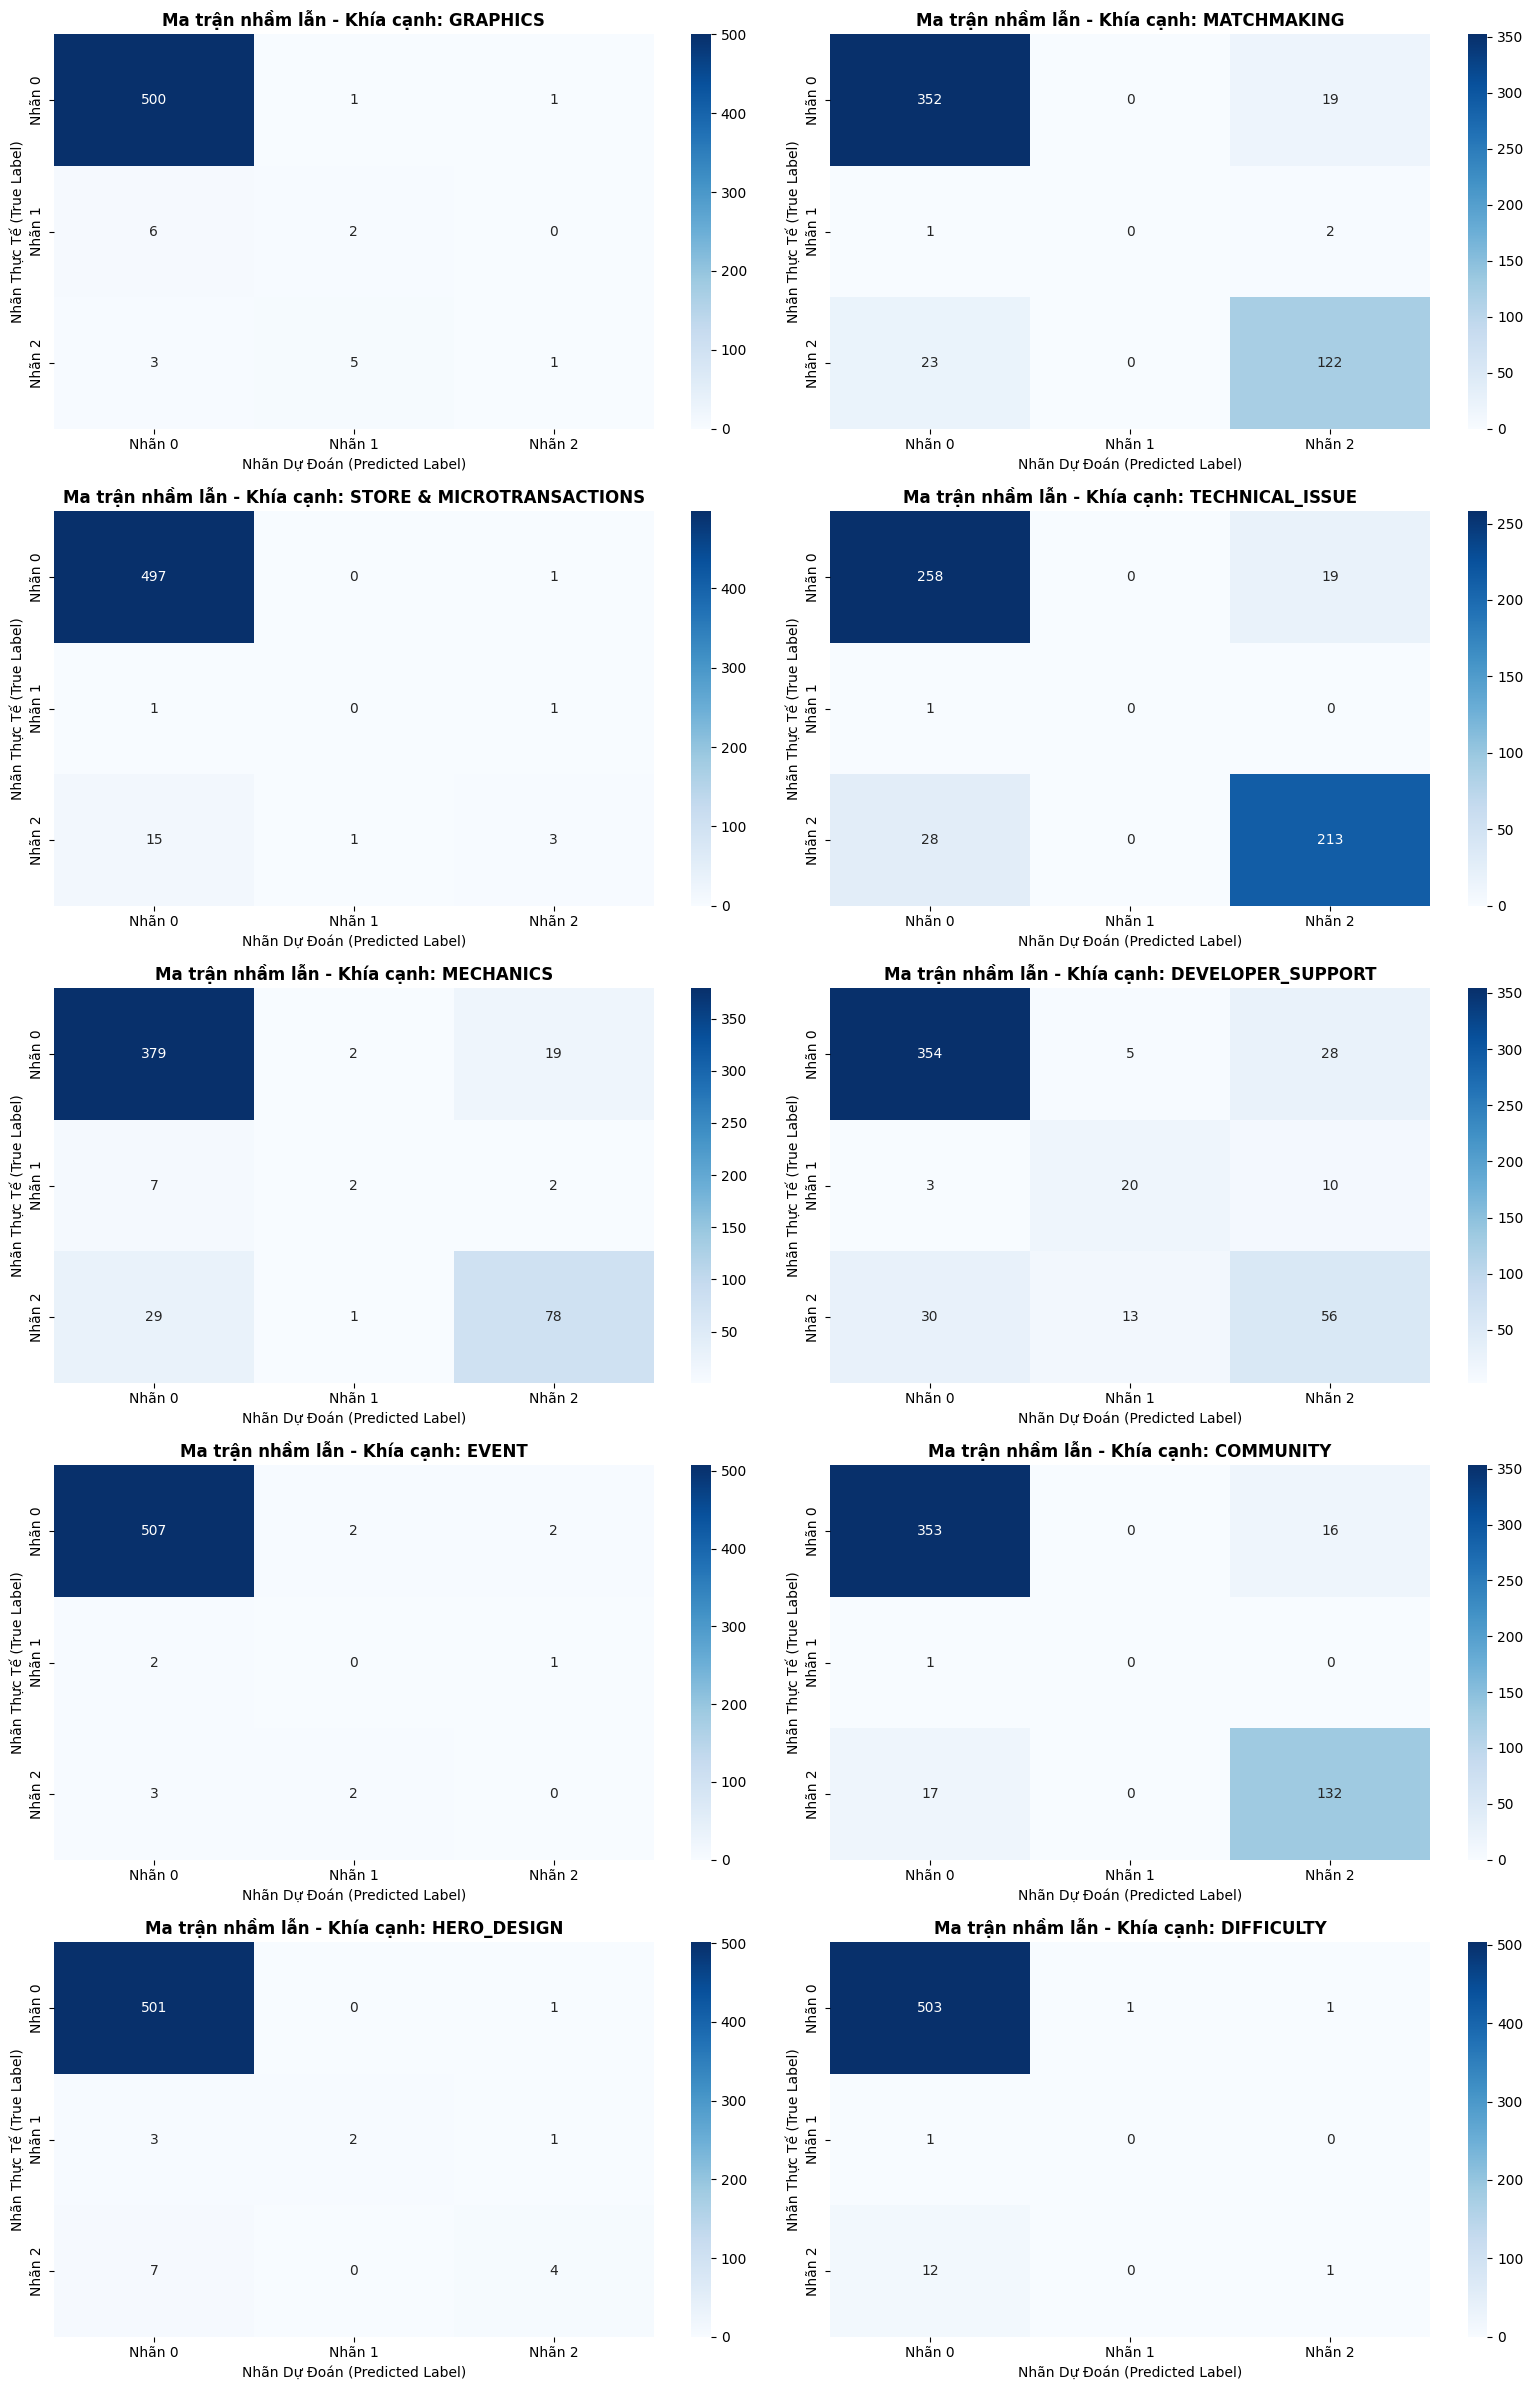

In [ ]:
# Cấu hình khung lưới hiển thị ma trận nhầm lẫn cho 10 khía cạnh (5 hàng x 2 cột)
fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.ravel()

print("--- ĐANG ĐỒ THỊ HÓA MA TRẬN NHẦM LẪN TRÊN TẬP TEST ---")

for idx, col in enumerate(aspect_cols):
    # Lấy nhãn thực tế và nhãn dự đoán của khía cạnh hiện tại
    y_true_col = Y_test.iloc[:, idx]
    y_pred_col = Y_pred_test[:, idx]

    # Tính ma trận nhầm lẫn với đầy đủ các class định danh [0, 1, 2]
    cm = confusion_matrix(y_true_col, y_pred_col, labels=[0, 1, 2])

    # Vẽ biểu đồ nhiệt (Heatmap)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Nhãn 0', 'Nhãn 1', 'Nhãn 2'],
                yticklabels=['Nhãn 0', 'Nhãn 1', 'Nhãn 2'])

    axes[idx].set_title(f"Ma trận nhầm lẫn - Khía cạnh: {col.upper()}", fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Nhãn Thực Tế (True Label)')
    axes[idx].set_xlabel('Nhãn Dự Đoán (Predicted Label)')

plt.tight_layout()
plt.show()

Cell 3: Phần 2 - Xuất danh sách chi tiết các dòng đoán sai trên tập Test

In [ ]:
error_analysis_records = []

# Duyệt qua từng dòng dữ liệu trong tập test
for i in range(len(test)):
    comment_text = test['review'].iloc[i]
    svm_clean_text = test['svm_text'].iloc[i]

    # Kiểm tra xem dòng này sai ở những khía cạnh nào
    for idx, col in enumerate(aspect_cols):
        true_val = Y_test.iloc[i, idx]
        pred_val = Y_pred_test[i, idx]

        if true_val != pred_val:
            error_analysis_records.append({
                "Dòng Số (Index)": i,
                "Bình Luận Gốc (Review)": comment_text,
                "Văn Bản Hệ SVM (Cleaned)": svm_clean_text,
                "Khía Cạnh Bị Sai (Aspect)": col,
                "Nhãn Thực Tế (True)": true_val,
                "Mô Hình Đoán Sai (Pred)": pred_val
            })

df_errors = pd.DataFrame(error_analysis_records)
df_errors.to_csv("test_set_error_analysis.csv", index=False, encoding='utf-8')

print(f"Tìm thấy tổng cộng {len(df_errors)} trường hợp đoán sai trên tổng số tất cả các khía cạnh.")
print("Đã lưu danh sách lỗi chi tiết vào file: test_set_error_analysis.csv")
print("\nHiển thị ngẫu nhiên 5 dòng đoán sai tiêu biểu:")
display(df_errors.sample(min(5, len(df_errors))))

Tìm thấy tổng cộng 350 trường hợp đoán sai trên tổng số tất cả các khía cạnh.
Đã lưu danh sách lỗi chi tiết vào file: test_set_error_analysis.csv

Hiển thị ngẫu nhiên 5 dòng đoán sai tiêu biểu:


,Dòng Số (Index),Bình Luận Gốc (Review),Văn Bản Hệ SVM (Cleaned),Khía Cạnh Bị Sai (Aspect),Nhãn Thực Tế (True),Mô Hình Đoán Sai (Pred)
85,112,chưa hỗ trợ 120 fps cho ss26untra,chưa_hỗ_trợ <NUM> fps cho ss26untra,developer_support,0,1
27,35,"chỉnh sửa tướng như tệ hại, con cần giảm không...",chỉnh_sửa tướng như tệ_hại con cần giảm không_...,matchmaking,2,0
26,35,"chỉnh sửa tướng như tệ hại, con cần giảm không...",chỉnh_sửa tướng như tệ_hại con cần giảm không_...,graphics,2,0
0,7,game gì đang có lỗi bị lag cũng không thèm fix...,game gì đang có lỗi bị lag cũng không_thèm fix...,developer_support,2,0
327,494,vẻ gì toàn chí mạng,vẻ gì toàn chí mạng,mechanics,2,0


Cell 4: Phần 3 - Kiểm tra 5 đặc tính cốt lõi của Bộ dữ liệu

In [ ]:
print("="*60)
print("PHÂN TÍCH ĐẶC TÍNH BỘ DỮ LIỆU HUẤN LUYỆN (TRAIN SET)")
print("="*60)

# Đặc tính 1: Mức độ mất cân bằng nhãn (Class Imbalance)
print("\n1. ĐẶC TÍNH MẤT CÂN BẰNG NHÃN (Phân phối nhãn 0, 1, 2 của các khía cạnh):")
label_distributions = {}
for col in aspect_cols:
    dist = train[col].value_counts().to_dict()
    label_distributions[col] = {str(k): dist.get(k, 0) for k in [0, 1, 2]}
print(pd.DataFrame(label_distributions).T)

# Đặc tính 2: Phân phối độ dài văn bản (Text Length Distribution)
word_counts = train['svm_text'].apply(lambda x: len(str(x).split()))
print(f"\n2. ĐẶC TÍNH ĐỘ DÀI VĂN BẢN (Tính theo số lượng từ):")
print(f" - Số từ trung bình mỗi câu: {word_counts.mean():.2f} từ")
print(f" - Câu ngắn nhất: {word_counts.min()} từ | Câu dài nhất: {word_counts.max()} từ")

# Đặc tính 3: Độ đa dạng từ vựng (Vocabulary Diversity)
all_words = " ".join(train['svm_text'].astype(str)).split()
unique_words = set(all_words)
ttr = len(unique_words) / len(all_words) if len(all_words) > 0 else 0
print(f"\n3. ĐỘ ĐA DẠNG TỪ VỰNG:")
print(f" - Tổng số từ xuất hiện (Tokens): {len(all_words)}")
print(f" - Số từ vựng duy nhất (Vocabulary Size): {len(unique_words)}")
print(f" - Tỷ lệ Đa dạng Từ vựng (Type-Token Ratio - TTR): {ttr:.4f} (Càng gần 1 càng đa dạng cao)")

# Đặc tính 4: Mật độ khía cạnh trong một câu (Multi-aspect Density)
active_aspects_per_comment = (train[aspect_cols] > 0).sum(axis=1)
print(f"\n4. MẬT ĐỘ KHÍA CẠNH TRONG CÂU:")
print(active_aspects_per_comment.value_counts().sort_index().rename(lambda x: f"Câu có {x} khía cạnh"))

# Đặc tính 5: Phân phối số lượng nhãn tích cực/tiêu cực/trung tính tổng thể
total_labels = train[aspect_cols].values.flatten()
print(f"\n5. TỔNG QUAN TỶ LỆ CÁC NHÃN TRÊN TOÀN BỘ DATASET:")
print(f" - Nhãn 0 (Không nhắc tới): {(total_labels == 0).sum()} dòng")
print(f" - Nhãn 1 (Bình thường/Tích cực): {(total_labels == 1).sum()} dòng")
print(f" - Nhãn 2 (Tiêu cực/Tệ hại): {(total_labels == 2).sum()} dòng")

PHÂN TÍCH ĐẶC TÍNH BỘ DỮ LIỆU HUẤN LUYỆN (TRAIN SET)

1. ĐẶC TÍNH MẤT CÂN BẰNG NHÃN (Phân phối nhãn 0, 1, 2 của các khía cạnh):
                              0    1     2
graphics                   4010   76    66
matchmaking                2919   18  1215
store & microtransactions  3994   25   133
technical_issue            2066   11  2075
mechanics                  3103   69   980
developer_support          3033  294   825
event                      4088   34    30
community                  2963    5  1184
hero_design                4010   57    85
difficulty                 4070   10    72

2. ĐẶC TÍNH ĐỘ DÀI VĂN BẢN (Tính theo số lượng từ):
 - Số từ trung bình mỗi câu: 16.45 từ
 - Câu ngắn nhất: 1 từ | Câu dài nhất: 122 từ

3. ĐỘ ĐA DẠNG TỪ VỰNG:
 - Tổng số từ xuất hiện (Tokens): 68315
 - Số từ vựng duy nhất (Vocabulary Size): 3549
 - Tỷ lệ Đa dạng Từ vựng (Type-Token Ratio - TTR): 0.0520 (Càng gần 1 càng đa dạng cao)

4. MẬT ĐỘ KHÍA CẠNH TRONG CÂU:
Câu có 0 khía cạnh     351
Câu 

Cell 5: Phần 4 - Code đối chiếu So sánh các kiểu nâng cấp cấu hình

In [ ]:
# Cấu hình mô hình Cơ bản ban đầu (Không tối ưu / Thô)
vec_base = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
X_tr_b = vec_base.fit_transform(train['svm_text'])
X_te_b = vec_base.transform(test['svm_text'])
model_base = MultiOutputClassifier(LinearSVC(C=1.0, random_state=42, max_iter=10000))
model_base.fit(X_tr_b, Y_train)
pred_base = model_base.predict(X_te_b)

# Cấu hình mô hình Đã Nâng cấp tối ưu (Fine-tuned)
vec_opt = TfidfVectorizer(ngram_range=(1, 3), min_df=2)
X_tr_o = vec_opt.fit_transform(train['svm_text'])
X_te_o = vec_opt.transform(test['svm_text'])
model_opt = MultiOutputClassifier(LinearSVC(C=0.5, class_weight='balanced', random_state=42, max_iter=10000))
model_opt.fit(X_tr_o, Y_train)
pred_opt = model_opt.predict(X_te_o)

# Lập bảng đối chiếu kết quả Macro F1
comparison_data = []
for idx, col in enumerate(aspect_cols):
    f1_b = f1_score(Y_test.iloc[:, idx], pred_base[:, idx], average='macro', zero_division=0)
    f1_o = f1_score(Y_test.iloc[:, idx], pred_opt[:, idx], average='macro', zero_division=0)
    comparison_data.append({
        "Khía Cạnh (Aspect)": col,
        "Mô hình Thô (Baseline F1)": round(f1_b, 4),
        "Mô hình Tối ưu (Fine-tuned F1)": round(f1_o, 4),
        "Mức độ Cải thiện (+/-)": round(f1_o - f1_b, 4)
    })

df_compare = pd.DataFrame(comparison_data)
# Thêm dòng trung bình tổng
mean_row_compare = {
    "Khía Cạnh (Aspect)": "TRUNG BÌNH TỔNG TẬP TEST",
    "Mô hình Thô (Baseline F1)": round(df_compare["Mô hình Thô (Baseline F1)"].mean(), 4),
    "Mô hình Tối ưu (Fine-tuned F1)": round(df_compare["Mô hình Tối ưu (Fine-tuned F1)"].mean(), 4),
    "Mức độ Cải thiện (+/-)": round(df_compare["Mức độ Cải thiện (+/-)"].mean(), 4)
}
df_compare = pd.concat([df_compare, pd.DataFrame([mean_row_compare])], ignore_index=True)

print("="*70)
print("BẢNG SO SÁNH HIỆU QUẢ CÁC KIỂU NÂNG CẤP CẤU HÌNH MÔ HÌNH")
print("="*70)
print(df_compare.to_string(index=False))

BẢNG SO SÁNH HIỆU QUẢ CÁC KIỂU NÂNG CẤP CẤU HÌNH MÔ HÌNH
       Khía Cạnh (Aspect)  Mô hình Thô (Baseline F1)  Mô hình Tối ưu (Fine-tuned F1)  Mức độ Cải thiện (+/-)
                 graphics                     0.4183                          0.4736                  0.0554
              matchmaking                     0.5933                          0.5966                  0.0032
store & microtransactions                     0.4150                          0.4111                 -0.0040
          technical_issue                     0.6051                          0.6052                  0.0001
                mechanics                     0.5520                          0.6446                  0.0925
        developer_support                     0.6880                          0.6861                 -0.0018
                    event                     0.3304                          0.3304                 -0.0000
                community                     0.6105                   

In [ ]:
# ============================================================
# XUẤT KẾT QUẢ DỰ ĐOÁN (PREDICT) RA FILE CSV
# ============================================================

# --- 1. Tạo DataFrame kết quả dự đoán trên tập TEST ---
df_pred_test = test[['review']].copy().reset_index(drop=True)

# Gán từng cột dự đoán tương ứng với từng khía cạnh
for idx, col in enumerate(aspect_cols):
    df_pred_test[f'pred_{col}'] = Y_pred_test[:, idx]

# --- 2. Xuất ra file CSV ---
output_filename = 'predictions_test.csv'
df_pred_test.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"Đã xuất kết quả dự đoán ra file: {output_filename}")
print(f"Tổng số dòng dự đoán: {len(df_pred_test)}")
print(f"Các cột trong file: {list(df_pred_test.columns)}")
print("\nXem trước 5 dòng đầu tiên:")
display(df_pred_test.head())

# --- 3. Tải file về máy (tùy chọn) ---
from google.colab import files
files.download(output_filename)
print(f"\nFile '{output_filename}' đã sẵn sàng để tải về.")

Đã xuất kết quả dự đoán ra file: predictions_test.csv
Tổng số dòng dự đoán: 519
Các cột trong file: ['review', 'pred_graphics', 'pred_matchmaking', 'pred_store & microtransactions', 'pred_technical_issue', 'pred_mechanics', 'pred_developer_support', 'pred_event', 'pred_community', 'pred_hero_design', 'pred_difficulty']

Xem trước 5 dòng đầu tiên:


,review,pred_graphics,pred_matchmaking,pred_store & microtransactions,pred_technical_issue,pred_mechanics,pred_developer_support,pred_event,pred_community,pred_hero_design,pred_difficulty
0,game thấy mình đánh hay toàn ghép chung với tụ...,0,2,0,0,0,0,0,2,0,0
1,tranh lane được mvp ra tố cáo không phát hiện ...,0,2,0,0,2,2,0,2,0,0
2,gắn bó với game cũng đã lâu và đầu tư rất nhiề...,0,0,0,2,0,2,0,0,0,0
3,sao không cho đăng nhập bằng facebook nữa,0,0,0,2,0,0,0,0,0,0
4,tôi cập nhật xong mất tài khoản luôn đang rank...,0,0,0,2,0,0,0,0,0,0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


File 'predictions_test.csv' đã sẵn sàng để tải về.


### Perform matching for 'svm_text' column

## Display Image

### Define Aspect Columns from `data_model`

In [9]:
# Dynamically identify aspect columns
# Exclude 'id', 'comment', 'qwen', 'svm', 'svm_text' and any other non-aspect columns
aspect_cols = [col for col in data_model.columns
               if col not in ['id', 'comment', 'qwen', 'svm', 'svm_text']
               and data_model[col].dtype in [np.int64, np.float64]]

print(f"Tìm thấy tất cả {len(aspect_cols)} khía cạnh trong data_model bao gồm:\n{aspect_cols}\n")

Tìm thấy tất cả 10 khía cạnh trong data_model bao gồm:
['graphics', 'matchmaking', 'store & microtransactions', 'technical_issue', 'mechanics', 'developer_support', 'event', 'community', 'hero_design', 'difficulty']



## Data Visualizations for `data_model.csv`

### 1.2 Độ dài câu (Word Count) trên toàn bộ `data_model`

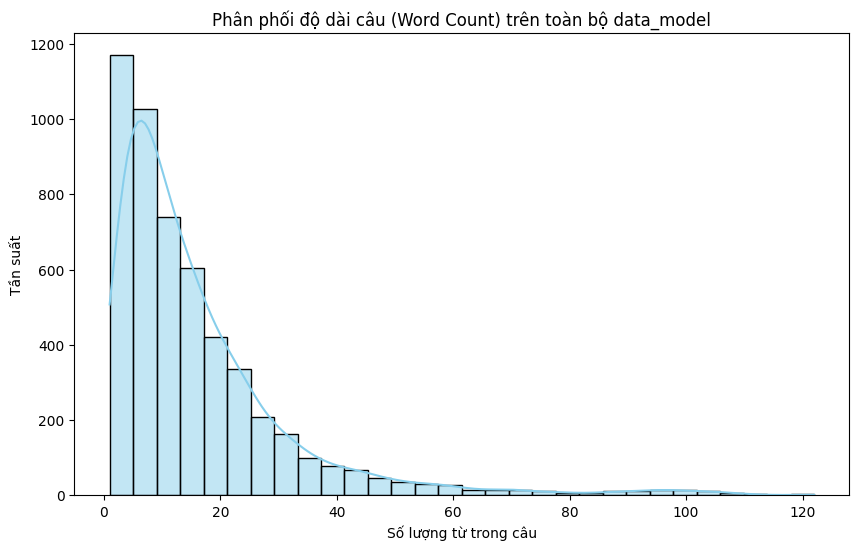

Số từ trung bình mỗi câu: 16.31
Câu ngắn nhất: 1 từ
Câu dài nhất: 122 từ


In [10]:
word_counts = data_model['svm_text'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.histplot(word_counts, bins=30, kde=True, color='skyblue')
plt.title('Phân phối độ dài câu (Word Count) trên toàn bộ data_model')
plt.xlabel('Số lượng từ trong câu')
plt.ylabel('Tần suất')
plt.show()

print(f"Số từ trung bình mỗi câu: {word_counts.mean():.2f}")
print(f"Câu ngắn nhất: {word_counts.min()} từ")
print(f"Câu dài nhất: {word_counts.max()} từ")

### 2.1 Phân phối nhãn trên từng khía cạnh (Label Distribution per Aspect) trên `data_model`

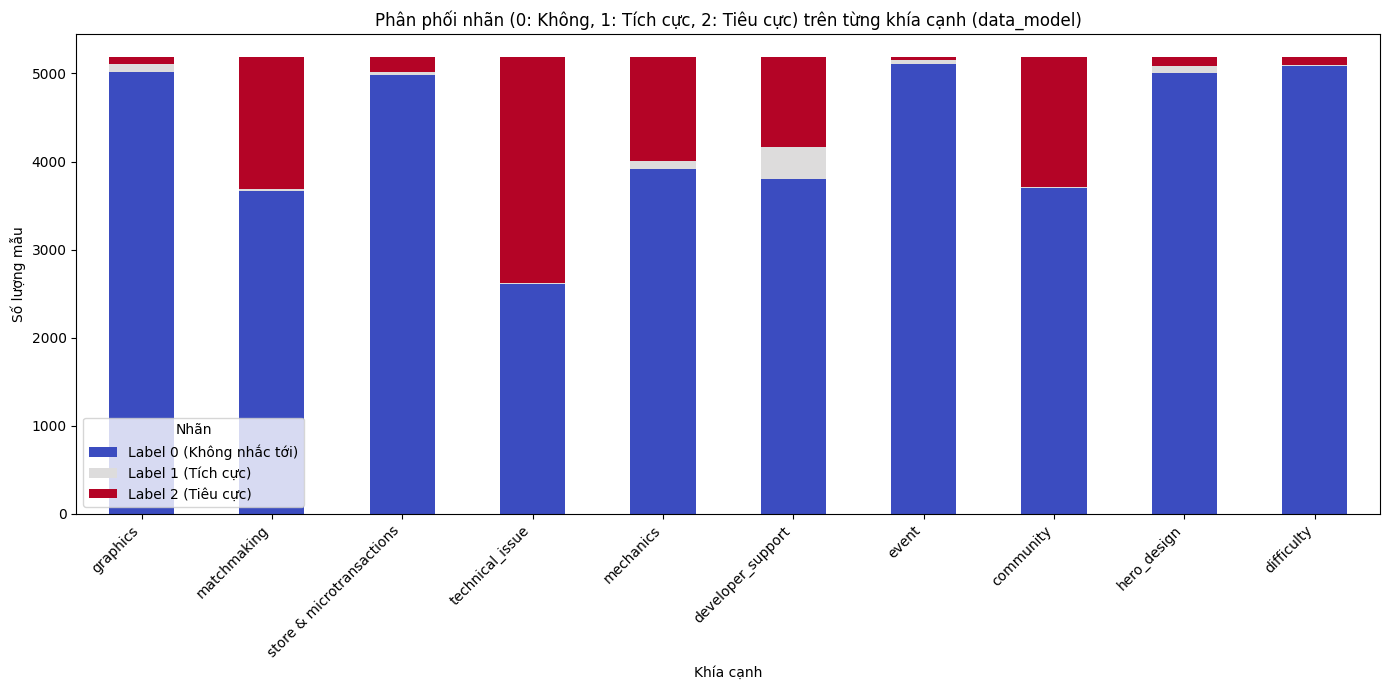

In [11]:
label_distributions = {}
for col in aspect_cols:
    dist = data_model[col].value_counts().to_dict()
    # Ensure all labels (0, 1, 2) are present, even if their count is 0
    label_distributions[col] = {str(k): dist.get(k, 0) for k in [0, 1, 2]}

df_label_dist = pd.DataFrame(label_distributions).T
df_label_dist.columns = ['Label 0 (Không nhắc tới)', 'Label 1 (Tích cực)', 'Label 2 (Tiêu cực)']

df_label_dist.plot(kind='bar', stacked=True, figsize=(14, 7), cmap='coolwarm')
plt.title('Phân phối nhãn (0: Không, 1: Tích cực, 2: Tiêu cực) trên từng khía cạnh (data_model)')
plt.xlabel('Khía cạnh')
plt.ylabel('Số lượng mẫu')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Nhãn')
plt.tight_layout()
plt.show()

### 2.2 Tỷ lệ nhãn Tiêu cực (Label 2) trong các mẫu có nhãn (Label 1 hoặc 2) trên `data_model`

/tmp/ipykernel_10716/3632043606.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Khía cạnh', y='Tỷ lệ Tiêu cực (Label 2)', data=df_negative_ratios, palette='rocket')


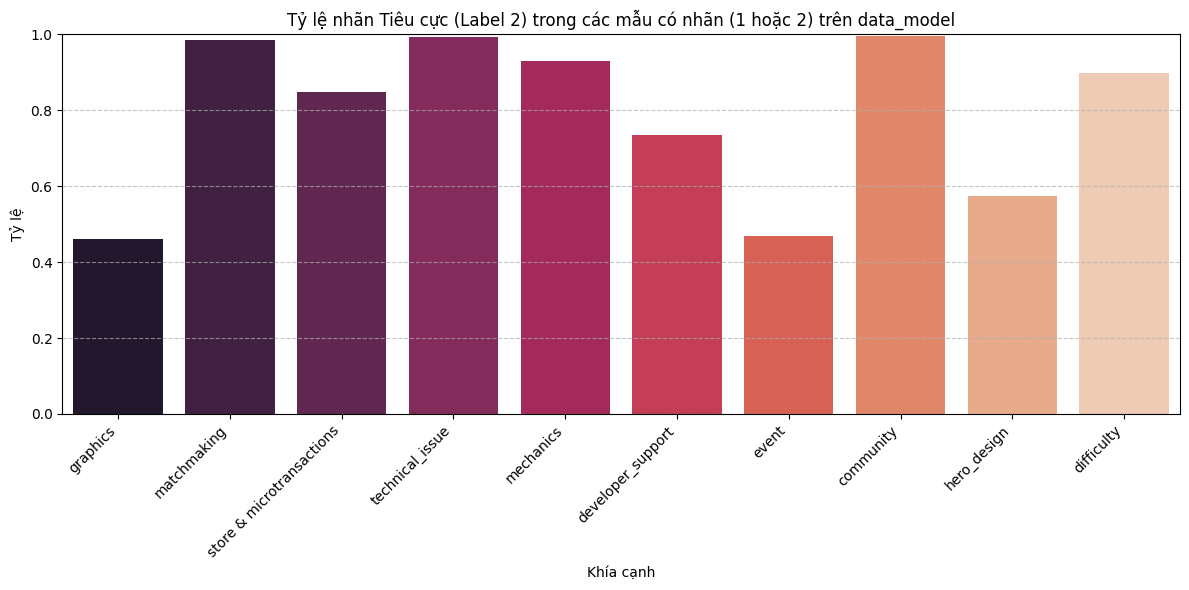

In [12]:
negative_ratios = {}
for col in aspect_cols:
    # Lấy các mẫu mà khía cạnh đó được gán nhãn (1 hoặc 2)
    labeled_samples = data_model[data_model[col] != 0]
    if not labeled_samples.empty:
        neg_count = (labeled_samples[col] == 2).sum()
        total_labeled = len(labeled_samples)
        negative_ratios[col] = neg_count / total_labeled
    else:
        negative_ratios[col] = 0.0 # No labeled samples for this aspect

df_negative_ratios = pd.DataFrame(list(negative_ratios.items()), columns=['Khía cạnh', 'Tỷ lệ Tiêu cực (Label 2)'])

plt.figure(figsize=(12, 6))
sns.barplot(x='Khía cạnh', y='Tỷ lệ Tiêu cực (Label 2)', data=df_negative_ratios, palette='rocket')
plt.title('Tỷ lệ nhãn Tiêu cực (Label 2) trong các mẫu có nhãn (1 hoặc 2) trên data_model')
plt.xlabel('Khía cạnh')
plt.ylabel('Tỷ lệ')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # Tỷ lệ nằm trong khoảng [0, 1]
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3.1 Số lượng khía cạnh (Aspects) trên mỗi mẫu trên `data_model`

/tmp/ipykernel_10716/612131899.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=active_aspects_per_comment, palette='magma')


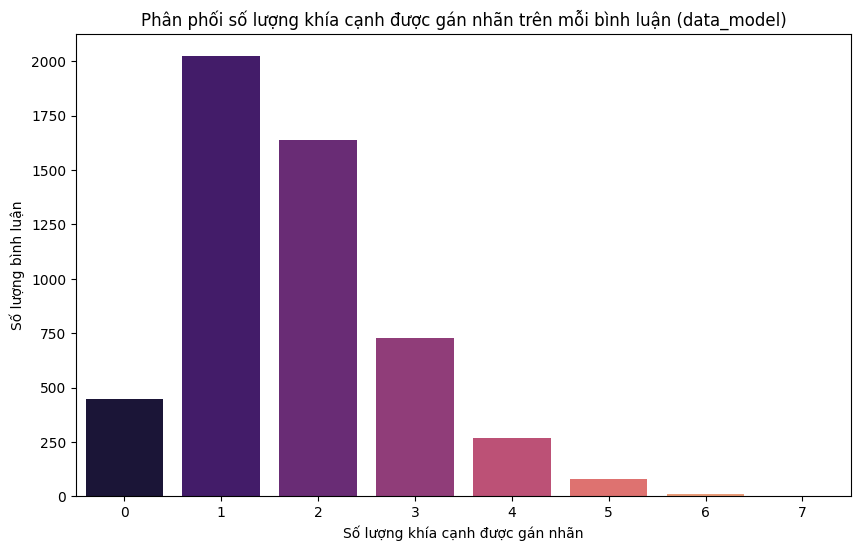

Phân phối chi tiết:
Câu có 0 khía cạnh     445
Câu có 1 khía cạnh    2024
Câu có 2 khía cạnh    1637
Câu có 3 khía cạnh     727
Câu có 4 khía cạnh     268
Câu có 5 khía cạnh      77
Câu có 6 khía cạnh      10
Câu có 7 khía cạnh       2
Name: count, dtype: int64


In [13]:
active_aspects_per_comment = (data_model[aspect_cols] > 0).sum(axis=1)

plt.figure(figsize=(10, 6))
sns.countplot(x=active_aspects_per_comment, palette='magma')
plt.title('Phân phối số lượng khía cạnh được gán nhãn trên mỗi bình luận (data_model)')
plt.xlabel('Số lượng khía cạnh được gán nhãn')
plt.ylabel('Số lượng bình luận')
plt.show()

print("Phân phối chi tiết:")
print(active_aspects_per_comment.value_counts().sort_index().rename(lambda x: f"Câu có {x} khía cạnh"))

### 3.2 Mối quan hệ giữa Độ dài câu (Word Count) và Số lượng khía cạnh (Aspects) trên mỗi mẫu trên `data_model`

/tmp/ipykernel_10716/3180641879.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='num_active_aspects', y='word_count', data=data_model, palette='cubehelix')


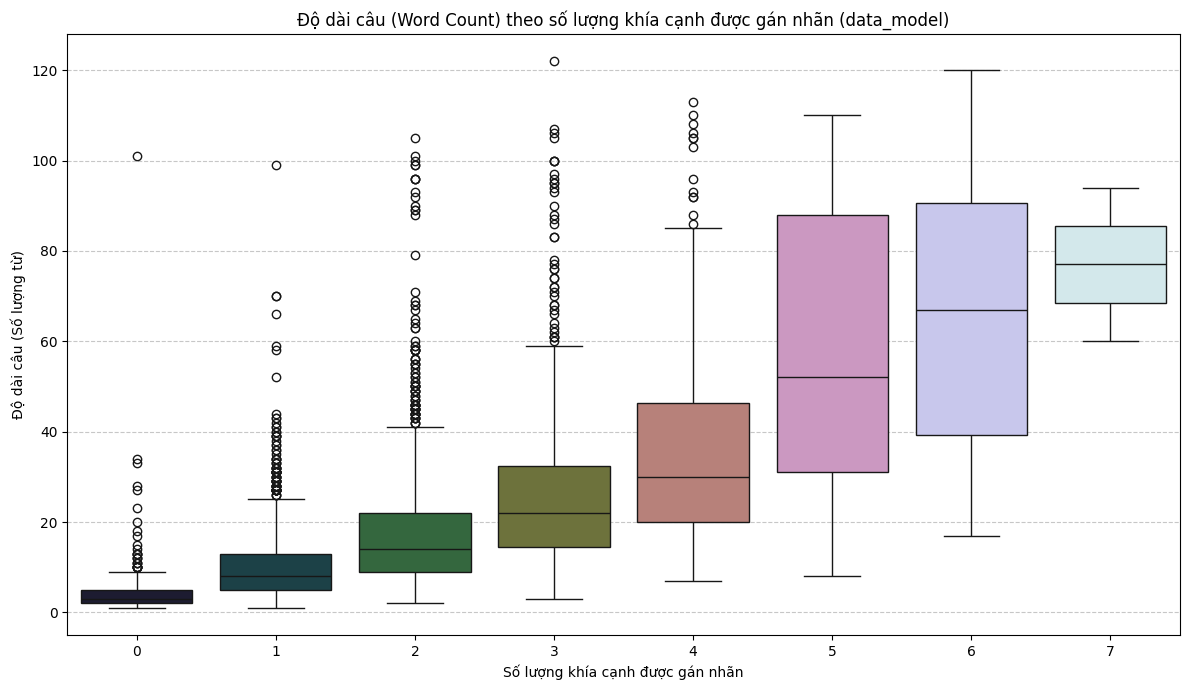

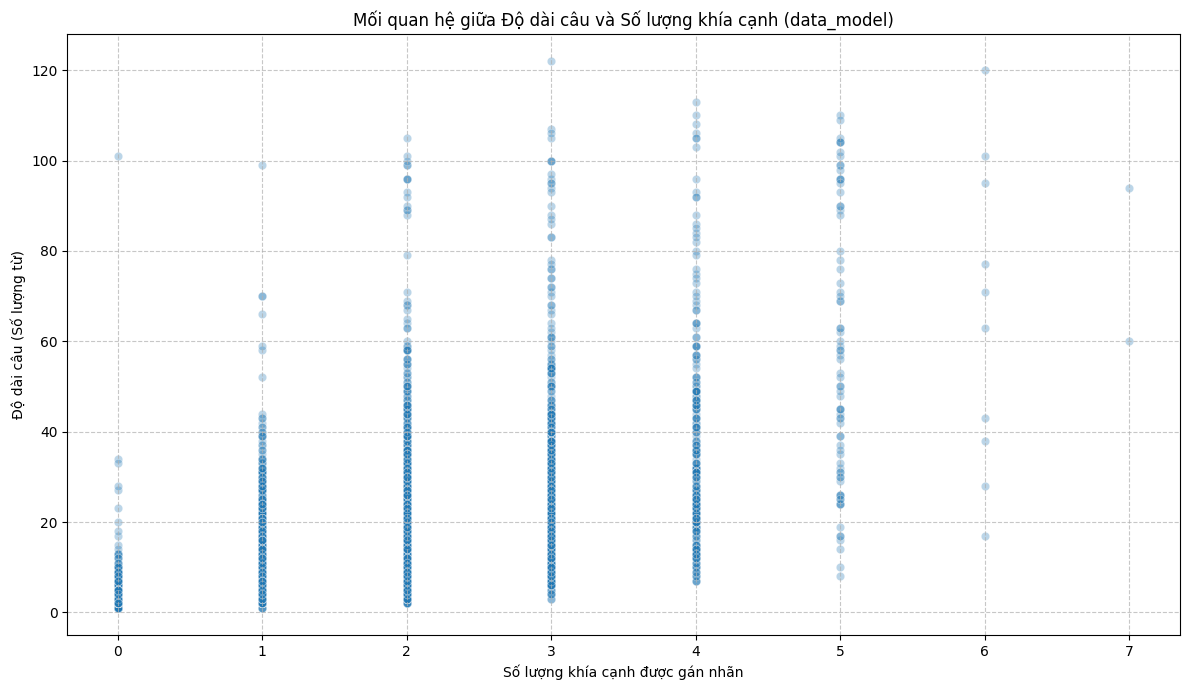

In [14]:
# Ensure 'word_count' is calculated for data_model
data_model['word_count'] = data_model['svm_text'].astype(str).apply(lambda x: len(x.split()))

# Calculate number of active aspects for each row in data_model
data_model['num_active_aspects'] = (data_model[aspect_cols] > 0).sum(axis=1)

plt.figure(figsize=(12, 7))
sns.boxplot(x='num_active_aspects', y='word_count', data=data_model, palette='cubehelix')
plt.title('Độ dài câu (Word Count) theo số lượng khía cạnh được gán nhãn (data_model)')
plt.xlabel('Số lượng khía cạnh được gán nhãn')
plt.ylabel('Độ dài câu (Số lượng từ)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Also show a scatter plot for clearer trend
plt.figure(figsize=(12, 7))
sns.scatterplot(x='num_active_aspects', y='word_count', data=data_model, alpha=0.3)
plt.title('Mối quan hệ giữa Độ dài câu và Số lượng khía cạnh (data_model)')
plt.xlabel('Số lượng khía cạnh được gán nhãn')
plt.ylabel('Độ dài câu (Số lượng từ)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()